In [ ]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


In [3]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [4]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [5]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [6]:
adjacency = radiusSearchCompactHashMap(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        domain.periodic, domain,
        mode, hashMapLength
)

Module wp_compactHash 46bb0ec load on device 'cuda:0' (block_dim=256) ...
            continue  # No particles in this cell

        dist_sq += dx * dx

                    edge_index += 1

                    edge_index += 1

            hashValue += wp.uint32(cellIndex[d] * primes[d])

            continue  # No particles in this cell

                    count += 1

                    count += 1

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_wp_compactHash_46bb0ec.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation ad

In [ ]:
from sphWarpCore.ops import computeSPHInterpolant_warpBackend, computeDensity_warpBackend


In [9]:
densities_warp = computeDensity_warpBackend(
        queryPositions, queryPositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        domain,
        mode = mode,
        adjacency = adjacency
)

queryDensities = densities_warp
referenceDensities = densities_warp

[Kernel.add_overload] Creating new overload for sphDensity_warp: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_a1i8_a1i8_a1i8_a1f4
Module wp_density 99cbc9d load on device 'cuda:0' (block_dim=256) ...
        rho += referenceMasses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2)

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eaf40a4.pch".  This usually occurs if the PCH 

In [10]:
f = torch.rand(x.shape[0], device = x.device)

f_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = mode,
        adjacency = adjacency
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_a1i8_a1i8_a1i8_a1f4
Module wp_interpolate 433adea load on device 'cuda:0' (block_dim=256) ...
            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

    Compile CUDA (arch=86, mode=release, block_dim=256) ...


Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eaf40a4.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_wp_radius_small_b00dc96.pch".  T

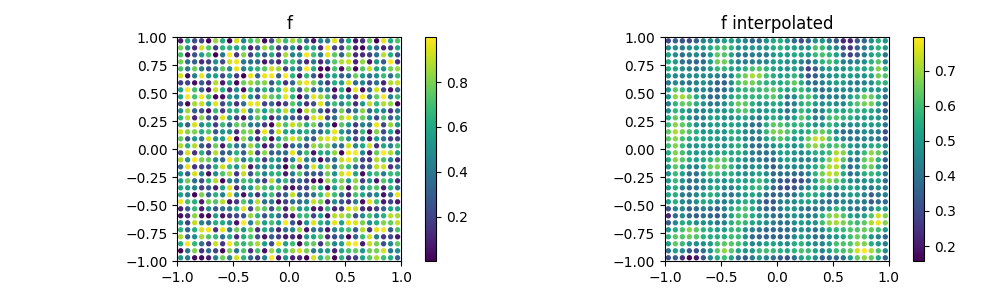

In [11]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1, 2, figsize = (10,3), squeeze = False)

markerSize = 8

c = axis[0,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = f.cpu(), s = markerSize)
axis[0,0].set_title("f")
fig.colorbar(c, ax = axis[0,0])

axis[0,0].set_aspect('equal', adjustable='box')
axis[0,0].set_xlim(-1,1)
axis[0,0].set_ylim(-1,1)


c = axis[0,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = f_interpolated.cpu(), s = markerSize)
axis[0,1].set_title("f interpolated")
fig.colorbar(c, ax = axis[0,1])

axis[0,1].set_aspect('equal', adjustable='box')
axis[0,1].set_xlim(-1,1)
axis[0,1].set_ylim(-1,1)

fig.tight_layout()

In [12]:
fvec = torch.rand((x.shape[0],2), device = x.device)

fvec_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        fvec, fvec,
        domain,
        mode = mode,
        adjacency = adjacency
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v2f4_a1v2f4_a1f4_a1f4_a1b_u4_a1i8_a1i8_a1i8_a1v2f4
[Module.load] Module hash changed, recompiling: wp_interpolate (433adeac -> 5f78612e)
Module wp_interpolate 5f78612 load on device 'cuda:0' (block_dim=256) ...
            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see do

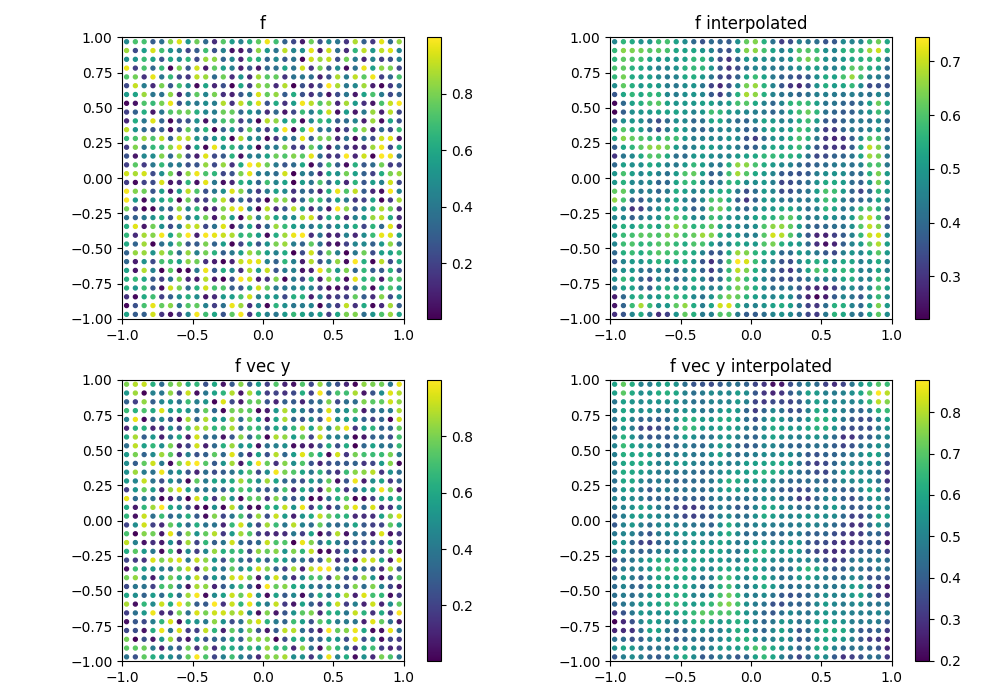

In [13]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(2, 2, figsize = (10,7), squeeze = False)

markerSize = 8

c = axis[0,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec[:,0].cpu(), s = markerSize)
axis[0,0].set_title("f")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec_interpolated[:,0].cpu(), s = markerSize)
axis[0,1].set_title("f interpolated")
fig.colorbar(c, ax = axis[0,1])

c = axis[1,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec[:,1].cpu(), s = markerSize)
axis[1,0].set_title("f vec y")
fig.colorbar(c, ax = axis[1,0])

c = axis[1,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec_interpolated[:,1].cpu(), s = markerSize)
axis[1,1].set_title("f vec y interpolated")
fig.colorbar(c, ax = axis[1,1])


for ax in axis.flatten():
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

fig.tight_layout()

In [14]:
f = torch.rand((x.shape[0],2,2), device = x.device)

f_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = mode,
        adjacency = adjacency
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1m22f4_a1m22f4_a1f4_a1f4_a1b_u4_a1i8_a1i8_a1i8_a1m22f4
[Module.load] Module hash changed, recompiling: wp_interpolate (5f78612e -> d704f838)
Module wp_interpolate d704f83 load on device 'cuda:0' (block_dim=256) ...
            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

    Compile CUDA (arch=86, mode=release, block_dim=256) ...


Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eaf40a4.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_wp_radius_small_b00dc96.pch".  T

In [15]:
f = torch.rand((x.shape[0],3,3,3), device = x.device)

f_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = mode,
        adjacency = adjacency
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v27f4_a1v27f4_a1f4_a1f4_a1b_u4_a1i8_a1i8_a1i8_a1v27f4
[Module.load] Module hash changed, recompiling: wp_interpolate (d704f838 -> 1d819255)
Module wp_interpolate 1d81925 load on device 'cuda:0' (block_dim=256) ...
            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

            f_interpolated += fieldValues[j] * masses[j] * wendland4_2d(pairwiseDistance, pairwiseSupport, 2) / densities[j]

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/